# Sphere and point

## I. Technical introduction and parameter justification :
This study aims to compare the moderation and shielding capabilities of three reference materials : 
- Light water ($H_2O$)
- Heavy water ($D_2O$)
- Graphite

To ensure the scientific validity of the results, the simulation parameters were selected based on statistical and physical criteria.

### &nbsp;&nbsp;&nbsp;&nbsp; 1. Statistical methodology

The simulation is performed using the OpenMC Monte Carlo code, which utilizes the pcg (permuted congruential generator), a pseudo-random number generator. The reliability of our results is based on two theoretical pillars :
* **Law of large numbers :** since each particle is simulated as an **independent and identically distributed event**, the statistical error on estimators (flux, current) decreases proportionally to the inverse of the square root of the number of histories regardless of the dimensionality of the sampled space. For this preliminary study, we aim for a relative error of approximately 0.03% (0.0003) giving :
  $$\sigma_{rel} = \frac{\sigma_{\bar{X}}}{\mu} = \frac{\sigma}{\mu \sqrt{N}}$$
  Since neutron transport follows a Poisson distribution, the intrinsic relative uncertainty of a single particle history is 100% ($\sigma/\mu = 1/\sqrt{1} = 1$)  :
  $$\implies \sigma_{rel} = \frac{1}{\sqrt{N}} \implies \sqrt{N} = \frac{1}{0.0003} \implies N = 1,000,000$$

* **Batching strategy :** rather than processing $N$ particles in a single block, we divide them into batches. According to the central limit theorem, the distribution of the means of each batch tends toward a normal distribution. This allows for the calculation of a robust variance and a realistic confidence interval for each score (tally).
  * **Selected parameters :** `nb_particles = 1,000,000` and `nb_batches = 10` (totaling $10^7$ histories). Utilizing 10 batches of 1M particles, rather than 100 batches of 100k is preferred to optimize memory usage and prevents RAM saturation.
  
## II. Geometric justification

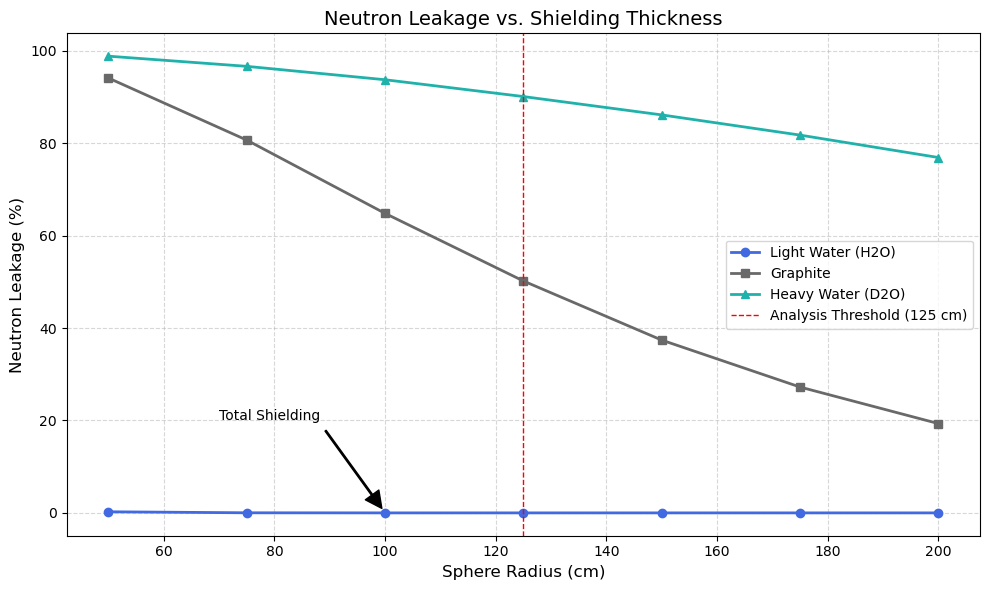

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
radii = np.array([50, 75, 100, 125, 150, 175, 200])
leakage_h2o = np.array([0.24, 0.02, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5]) # 1e-5 pour représenter le "0" en log
leakage_graphite = np.array([94.09, 80.66, 64.80, 50.17, 37.38, 27.22, 19.32])
leakage_d2o = np.array([98.82, 96.62, 93.72, 90.08, 86.11, 81.74, 76.89])

plt.figure(figsize=(10, 6))

# Plotting lines
plt.plot(radii, leakage_h2o, 'o-', label='Light Water (H2O)', color='royalblue', lw=2)
plt.plot(radii, leakage_graphite, 's-', label='Graphite', color='dimgray', lw=2)
plt.plot(radii, leakage_d2o, '^-', label='Heavy Water (D2O)', color='lightseagreen', lw=2)
plt.axvline(x=125, color='red', linestyle='--', lw=1, label='Analysis Threshold (125 cm)')

# Formatting
plt.xlabel('Sphere Radius (cm)', fontsize=12)
plt.ylabel('Neutron Leakage (%)', fontsize=12)
plt.title('Neutron Leakage vs. Shielding Thickness', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

# Adding an annotation for the "0%" Water
plt.annotate('Total Shielding', xy=(100, 1e-5), xytext=(70, 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

Following a sensitivity analysis of neutron leakage across various dimensions (from $r=50 cm$ to $200 cm$), it was concluded that the 125 cm radius represents the most effective scale for this comparative study. It provides the "ideal window" to observe the diverging physics of the three selected materials.

This choice is supported by the following practical criteria :
- Optimal contrast threshold :
    - **Light water ($H_2O$) :** reaches total extinction (shielding regime).
    - **Graphite ($\approx50$ %) :** reaches its relaxation lenght. It serves as the perfect median pivot point, showing exactly half of the neutron population being attenuated.
    - **Heavy water ($D_2O$) :** remains near-transparent (diffusion regime).
    
The sensitivity analysis showed that outside of this specific radius, the results tend to converge (for graphite and heavy water below and for graphite and light water above). Choosing 125 cm ensures they remain very distinct, making it easier to clearly discriminate between the moderation properties of these materials. This dimension allows the 2D spatial flux maps to develop a visible color gradient. Instead of a uniformly "saturated" or "extinguished" sphere, the transition of the flux becomes visually explicit, making the physical concept of migration length much easier to interpret in the final results.

## III. Nuclear data
For maximum precision, the simulation rely on the H5 continuous-energy at 293.6 K nuclear data libraries from the `JEFF-3.3-HDF5` library containing the precise cross-sections required to accurately model scattering phenomena and thermal capture.

In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm.auto import tqdm
import time

#cleaning 
!rm -r *h5

# Study Parameters
sphere_radius = 125 # in cm
nb_particles = 1000000
nb_batches = 10
mesh_size = 300

/home/clem/miniconda3/envs/openmcenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## IV. Material definitions and nuclear properties
In this section, we define the three media used for the comparative study. For a monte carlo simulation to be physically accurate, each material must be characterized by three key properties :
- **Isotopic composition :** The precise atomic ratios (e.g., $H/O = 2$) which dictate the probability of specific neutron interactions.
- **Mass density :** This defines the "atom packing," determining the macroscopic cross-section ($\Sigma$) and thus the mean free path of neutrons.
- **Thermal scattering data ($S(\alpha, \beta)$) :** Essential for low-energy neutrons, these laws account for the chemical bonds of the atoms (e.g., `c_H_in_H2O`, `c_D_in_D2O`, `c_Graphite`), which significantly affect the final thermalization profile.

In [3]:
mats = openmc.Materials()

# 1. Water (H2O)
water = openmc.Material(material_id=1, name="light_water")
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)
water.add_s_alpha_beta('c_H_in_H2O') 

# 2. Heavy Water (D2O)
heavy_water = openmc.Material(material_id=2, name="heavy_water")
heavy_water.add_nuclide('H2', 2.0)
heavy_water.add_nuclide('O16', 1.0)
heavy_water.set_density('g/cm3', 1.1) # Densité plus élevée que H2O
heavy_water.add_s_alpha_beta('c_D_in_D2O') 

# 3. Graphite (Nuclear Grade)
graphite = openmc.Material(material_id=3, name="graphite")
graphite.add_element('C', 1.0)
graphite.set_density('g/cm3', 1.7) # Densité typique du graphite nucléaire
graphite.add_s_alpha_beta('c_Graphite') 


# adding and exporting material
mats.append(water)
mats.append(heavy_water)
mats.append(graphite)

mats.export_to_xml()

#print(mats)

## V. Geometry
### &nbsp;&nbsp;&nbsp;&nbsp; 1. Definition
The model is a simple sphere of radius 125 cm with a `vacuum` boundary condition, ensuring that any neutron leaving the surface is counted as "leakage."

In [4]:
# Surfaces
external_surface = openmc.Sphere(r=sphere_radius, boundary_type='vacuum')

# Cells
cell = openmc.Cell(fill=water, region=-external_surface)

#universe
univ = openmc.Universe(cells=[cell])

#final geometry
geom = openmc.Geometry(univ)
geom.export_to_xml()

#!cat geometry.xml

#### &nbsp;&nbsp;&nbsp;&nbsp; 2. Visualization

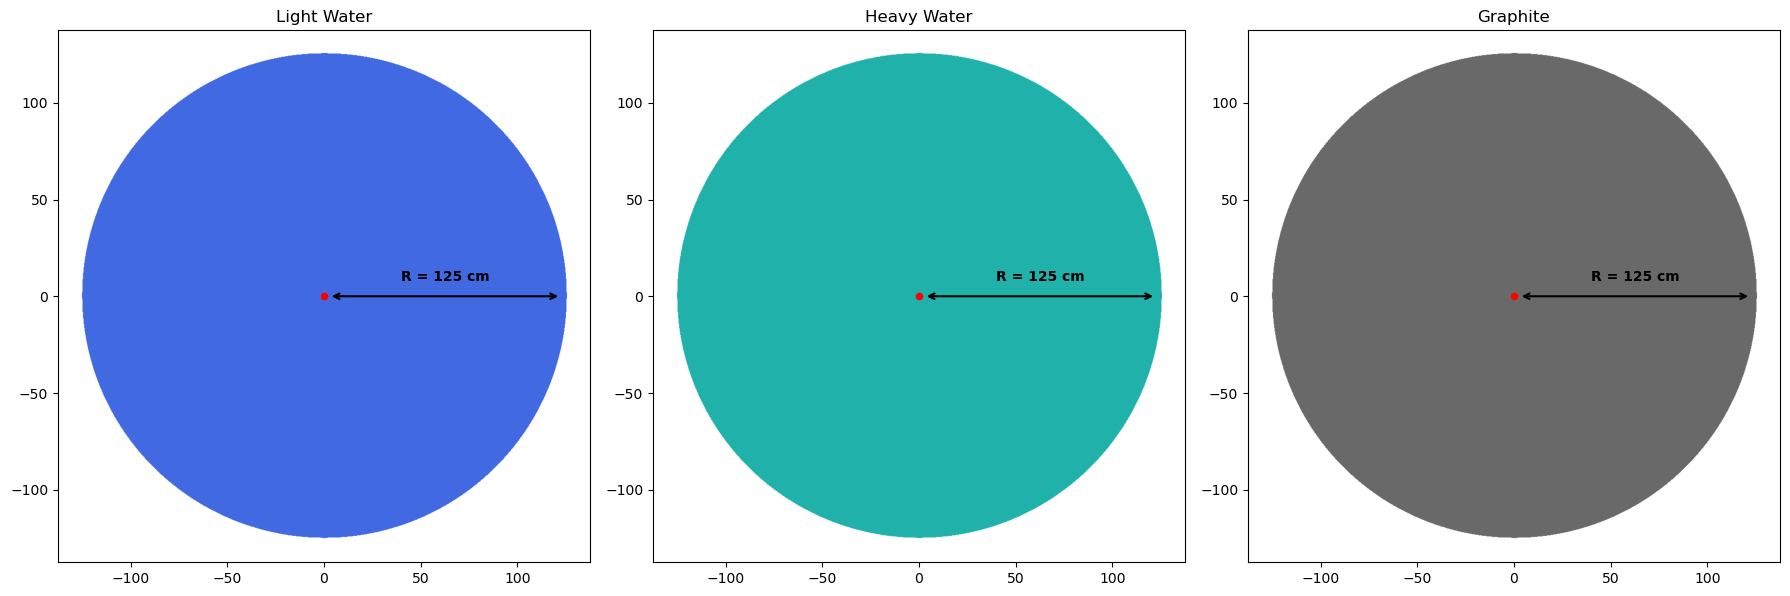

In [5]:
fig, axes_list = plt.subplots(1, 3, figsize=(18, 6))

plot_configs = [
    (water, 'Light Water', 'royalblue'),
    (heavy_water, 'Heavy Water', 'lightseagreen'),
    (graphite, 'Graphite', 'dimgray')
]

for i, (mat, name, color_code) in enumerate(plot_configs):
    ax = axes_list[i]
    cell.fill = mat
    
    # Visualizing the geometry slice
    univ.plot(width=(sphere_radius * 2.2, sphere_radius * 2.2), 
              basis='xy', 
              color_by='material', 
              colors={mat: color_code},
              axes=ax,
              pixels=1000000)
    
    # Marking the point source at the center
    ax.scatter(0, 0, color='red', s=20, label='Source', zorder=5)
    
    # Adding radius annotation for scale clarity
    ax.annotate('', xy=(sphere_radius*0.98, 0), xytext=(sphere_radius*0.02, 0), arrowprops=dict(arrowstyle='<->', color='Black', lw=1.5))
    ax.text(sphere_radius/2, 8, f'R = {sphere_radius} cm', 
            color='Black', fontsize=10, ha='center', fontweight='bold')

    ax.set_title(f"{name}")
    
plt.tight_layout()
plt.show()

## VI. Source defintion
A point source is placed at the center of the sphere, emitting neutrons with a Watt fission spectrum to simulate an energy distribution from nuclear fission.

In [6]:
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, 0))
source.energy = openmc.stats.Watt() 

## VII. Settings

In [7]:
sett = openmc.Settings()
sett.source = source
sett.particles = nb_particles
sett.batches = nb_batches
sett.run_mode = 'fixed source'

sett.export_to_xml()
#!cat settings.xml

## VIII. Meshing
A 2D regular mesh of $300 \times 300$ cells is defined to discretize the sphere’s cross-section.

In [8]:
# Create mesh
mesh = openmc.RegularMesh()
mesh.dimension = [mesh_size, mesh_size, 1]
mesh.lower_left = [-sphere_radius, -sphere_radius, -1]
mesh.upper_right = [sphere_radius, sphere_radius, 1]

# Create filter (average in every mesh not only a global one)
mesh_filter = openmc.MeshFilter(mesh)

## IX. Tallies
The tallies are set up to track the neutron's journey from birth to escape/absorption. We'll cross-reference these metrics to evaluate the materials properties.

The **flux spectrum** and **spatial flux** work together. One tells us if the neutrons are actually slowing down (thermalizing), while the other shows how far they travel before doing so. This is how we visualize the "moderation zone."

The **leakage current** at the 125 cm boundary measures the neutron economy. For a moderator, high leakage is only a "win" if the spectrum confirms those neutrons are thermal.

The **moderation time** adds the final dimension. It's not enough to moderate neutrons ; we need to know how fast it happens. A long moderation time (like in graphite) increases the risk of capture, even if the final spectrum looks good.

In short, these tallies allow us to distinguish a shield (low leakage, fast extinction) from a transparent medium (high leakage, fast neutrons) or a true moderator (high leakage, thermalized neutrons). All these metrics are essential if we are to conduct a relevant analysis of these media as moderators within an iso-distance study.

In [9]:
tallies = openmc.Tallies()

# 1. Energy Spectrum Tally
energies = np.logspace(-5, 7, 501)
e_filter = openmc.EnergyFilter(energies)
spec_tally = openmc.Tally(name='flux_spectrum')
spec_tally.filters = [e_filter]
spec_tally.scores = ['flux']
tallies.append(spec_tally)

# 2. Spatial Flux Tally
mesh_tally = openmc.Tally(name='spatial_flux')
mesh_tally.filters = [mesh_filter]
mesh_tally.scores = ['flux']
tallies.append(mesh_tally)

# 3. Leakage Tally
# Requires a surface filter on the outer boundary of your sphere
surf_filter = openmc.SurfaceFilter([external_surface]) 
leak_tally = openmc.Tally(name='leakage_current')
leak_tally.filters = [surf_filter]
leak_tally.scores = ['current'] 
tallies.append(leak_tally)

# 4. Moderation Time Tally
# Tracks how long neutrons stay in the system
times = np.logspace(-9, -2, 101) # From nano-s to centi-s
t_filter = openmc.TimeFilter(times)
time_tally = openmc.Tally(name='moderation_time')
time_tally.filters = [t_filter]
time_tally.scores = ['flux']
tallies.append(time_tally)

# 5. Absorption Rate Tally
# This tracks the physical disappearance of neutrons by capture/absorption
abs_tally = openmc.Tally(name='absorption_rate')
abs_tally.scores = ['absorption']
tallies.append(abs_tally)


tallies.export_to_xml()

## X. Running OpenMC
The three materials are processed through an automated loop. For each material, the geometry is updated, the transport simulation is executed, and the results are harvested directly from the OpenMC statepoint files. Each simulation uses the same source, mesh, and tallies, meaning the differences observed are only due to material cross-sections. The Leakage Current is captured at the boundary to finalize the neutron balance (leakage/absorption).

In [10]:
material_list = [(water, 'light_water'), (graphite, 'graphite'), (heavy_water, 'heavy_water')]

# Initialize data containers for post-processing
results_2d = {}
results_spectrum = {}
results_time = {}      
results_leakage = {}   
results_abs = {}

for mat_obj, name in material_list:
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print(f"Configuration: {nb_particles} particles | {nb_batches} batches")
    print(f"{'='*60}")
    
    # Update geometry and export
    cell.fill = mat_obj
    geom.export_to_xml()
    
    openmc.run(output=False)     
    
    # Access the statepoint file to harvest tally results
    statepoint_file = f'statepoint.{nb_batches}.h5'
    with openmc.StatePoint(statepoint_file) as sp:
        
        # 1. SPATIAL FLUX (2D)
        # Reshape the flat array into the spatial mesh grid
        raw_data = sp.get_tally(name='spatial_flux').get_values(scores=['flux'])
        results_2d[name] = raw_data.reshape((mesh_size, mesh_size)).copy()
        
        # 2. ENERGY SPECTRUM 
        # Capture the mean flux values across the defined energy bins
        spec_data = sp.get_tally(name='flux_spectrum').mean.flatten()
        results_spectrum[name] = spec_data.copy()

        # 3. MODERATION TIME 
        # Harvest the flux distribution as a function of neutron 'time-of-flight'
        time_data = sp.get_tally(name='moderation_time').mean.flatten()
        results_time[name] = time_data.copy()

        # 4. NEUTRON LEAKAGE AND ABSORPTION
        # Extract the global integral values for the final balance sheet
        results_leakage[name] = sp.get_tally(name='leakage_current').mean.sum()
        results_abs[name] = sp.get_tally(name='absorption_rate').mean.sum()
        
        elapsed_time = time.time() - start_time
        print(f"✅ {name.upper()} processed in {elapsed_time:.2f} s")
        
print('')
print("--- Simulation Sequence Complete, data Saved ---")


LIGHT_WATER
Configuration: 1000000 particles | 10 batches
✅ LIGHT_WATER processed in 993.62 s

GRAPHITE
Configuration: 1000000 particles | 10 batches
✅ GRAPHITE processed in 2808.60 s

HEAVY_WATER
Configuration: 1000000 particles | 10 batches
✅ HEAVY_WATER processed in 6800.82 s

--- Simulation Sequence Complete, data Saved ---


## XI. Post-processing
### &nbsp;&nbsp;&nbsp;&nbsp; 1. Spectrum comparison

This section visualizes the neutron flux distribution across the 3 different materials ($H_2O$, $D_2O$ and graphite). To compare these materials effectively, we'll transform the raw flux into a "lethargy-normalized flux".
Neutron energies span over nine orders of magnitude ($10^{-3}$ eV to $10^{7}$ eV). On a linear energy scale, the thermal peak would be compressed into a nearly invisible vertical line compared to the vast energy span of the fission spectrum.

A neutron does not lose its energy linearly, but rather by a constant fraction of its energy with each collision. This is why we use lethargy, defined as $u = \ln(E_0/E)$, which is "in a way, a measure of the 'age' of the neutron as it undergoes moderation" (P. REUSS). By imposing the conservation of the neutron population, we can write :
$$dn = \phi(u)du = |\phi(E)dE| \quad \text{and since} \quad |du| = \frac{dE}{E}$$
$$\implies \phi(u) \cdot \frac{dE}{E} = \phi(E)dE \implies \phi(u) = E \cdot \phi(E)$$

In the epithermal range, the flux density follows a $1/E$ distribution. By plotting the lethargy flux $\phi(u)$ (or $E\phi(E)$) on a logarithmic energy axis flattens into a horizontal line making it easier to spot physical deviations or resonances, and ensures that the area under the curve is directly proportional to the total neutron population.

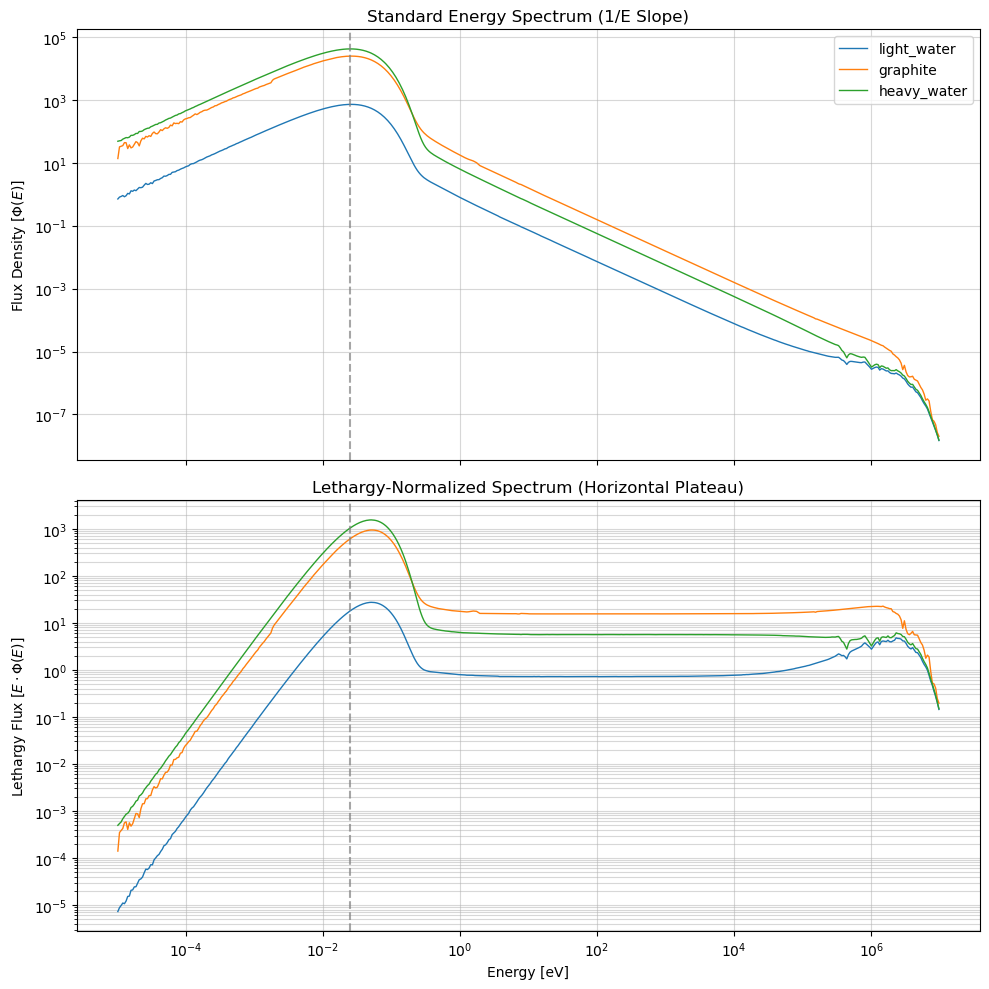

In [11]:
# Create a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Calculate geometric centers and bin widths
energy_centers = np.sqrt(energies[:-1] * energies[1:])
bin_widths = np.diff(energies)

for mat_obj, name in material_list:
    flux_vals = results_spectrum[name]
    # Calculate the standard flux density Phi(E)
    phi_e = flux_vals / bin_widths
    
    # 1. First plot: Standard Flux Phi(E)
    # Using log-log because Phi(E) spans several orders of magnitude
    ax1.loglog(energy_centers, phi_e, label=name, lw=1)
    
    # 2. Second plot: Lethargy Flux E * Phi(E)
    ax2.loglog(energy_centers, phi_e * energy_centers, label=name, lw=1)

# Configuration for the first plot (Standard)
ax1.set_ylabel(r'Flux Density [$\Phi(E)$]')
ax1.set_title('Standard Energy Spectrum (1/E Slope)')
ax1.grid(True, which="both", ls="-", alpha=0.5)

ax1.legend()

# Configuration for the second plot (Lethargy)
ax2.set_xlabel('Energy [eV]')
ax2.set_ylabel(r'Lethargy Flux [$E \cdot \Phi(E)$]')
ax2.set_title('Lethargy-Normalized Spectrum (Horizontal Plateau)')
ax2.grid(True, which="both", ls="-", alpha=0.5)

# Thermal reference line on both plots
for ax in [ax1, ax2]:
    ax.axvline(x=0.0253, color='grey', linestyle='--', alpha=0.7, label='0.025 eV (Thermal)')

plt.tight_layout()
plt.show()

##### Computational methodology
The script processes the tally results using the following steps : 
- **Geometric bin centers :** Calculated as $E_{center} = \sqrt{E_{i} \cdot E_{i+1}}$. This is the precise midpoint on a logarithmic axis.
- **Flux density normalization :** Raw tally results are normalized by the bin width ($\Delta E$) to compute the flux density $\Phi(E)$.
- **Thermal reference :** A vertical marker is placed at 0.0253 eV, representing the most probable energy of neutrons in thermal equilibrium at 20°C.

Material     | E_peak (eV)  | Flux_max
light_water  | 0.0511       | 2.73e+01
graphite     | 0.0511       | 9.43e+02
heavy_water  | 0.0511       | 1.55e+03
Mean of peaks : 0.0511 eV


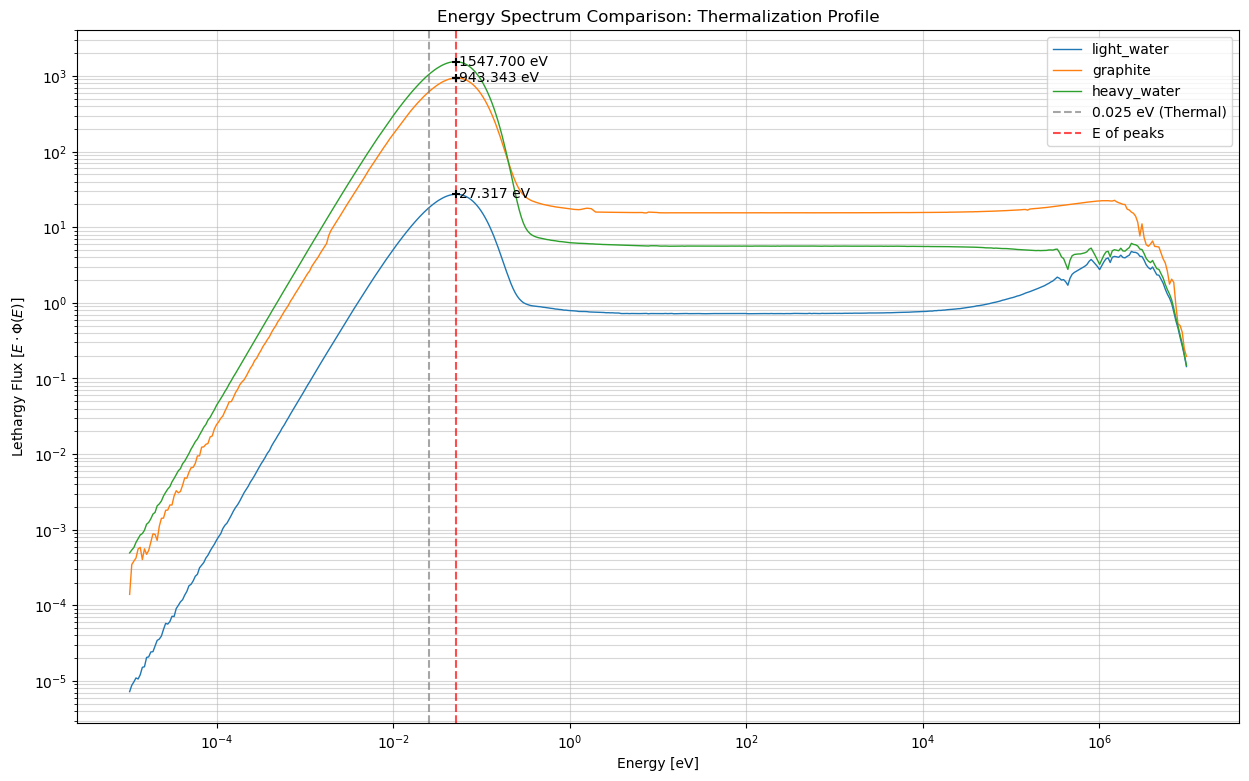

In [12]:
plt.figure(figsize=(15, 9))

# Geometric bin centers
energy_centers = np.sqrt(energies[:-1] * energies[1:])
bin_widths = np.diff(energies)
peaks=[]
#printing maxes tab
print(f"{'Material':<12} | {'E_peak (eV)':<12} | {'Flux_max'}")
for mat_obj, name in material_list:
    y = (results_spectrum[name] / bin_widths) * energy_centers
    idx = np.argmax(y[energy_centers < 1])
    peaks.append(y[idx])
    print(f"{name:<12} | {energy_centers[idx]:<12.4f} | {y[idx]:.2e}")
e_max_list = [energy_centers[np.argmax((results_spectrum[m[1]]/bin_widths)*energy_centers * (energy_centers < 1))] for m in material_list]
e_peak=np.mean(e_max_list)
print(f"Mean of peaks : {e_peak:.4f} eV")

i=0
for mat_obj, name in material_list:
    # Retrieve tally results for the specific material
    flux_vals = results_spectrum[name]
    # Flux density conversion
    plt.loglog(energy_centers, (flux_vals / bin_widths) * energy_centers, label=name, lw=1)
    plt.scatter(e_peak, peaks[i],marker='+', color='Black', s=30, zorder=5)
    plt.text(e_peak * 1.1, peaks[i], f"{peaks[i]:.3f} eV", fontsize=10, verticalalignment='center')
    i+=1

# Thermal reference line
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.minorticks_on()
plt.xlabel('Energy [eV]')
plt.ylabel(r'Lethargy Flux [$E \cdot \Phi(E)$]')
plt.title('Energy Spectrum Comparison: Thermalization Profile')
plt.axvline(x=0.0253, color='grey', linestyle='--', alpha=0.7, label='0.025 eV (Thermal)')
plt.axvline(x=e_peak, color='red', linestyle='--', alpha=0.7, label='E of peaks')
plt.legend()
plt.show()

### &nbsp;&nbsp;&nbsp;&nbsp; 2. Moderation time

The slowing-down time represents the duration between a neutron's birth and the moment it reaches a specific energy threshold (thermal for moderators study).
It's essential for moderator characterization because : 
- It quantifies moderation speed, providing a "material signature".
- It determines the neutron "lifetime", a fundamental parameter to describe the system dynamics.

Just as with the energy spectrum, the script processes the temporal data to ensure accurate visualization through :
- Geometric centering.
- Log-log representation allowing the simultaneous observation of : 
    - The slowing-down phase (typically appearing as a plateau or a steady slope).
    - The thermalization and decay phase (the final roll-off of the curve).

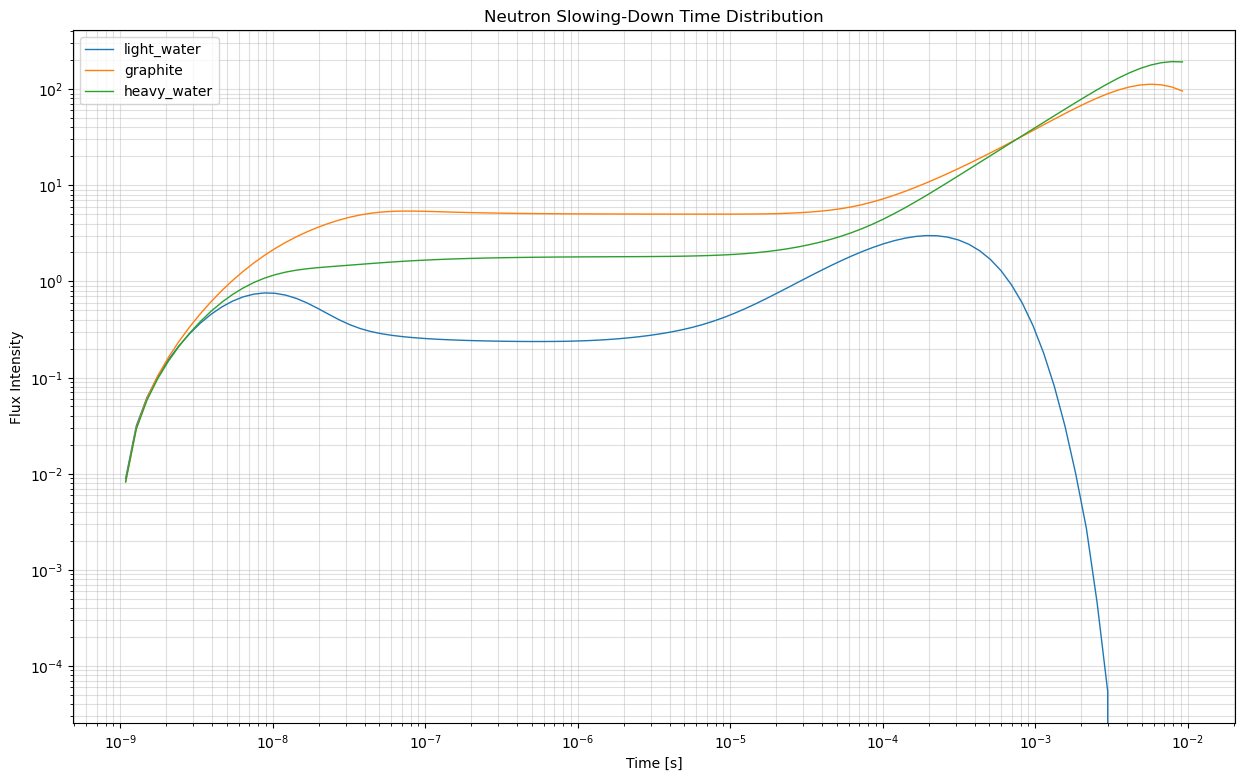

In [ ]:
plt.figure(figsize=(15, 9))

# Loop on materials
for name in results_spectrum.keys():
    time_vals = results_time[name] 
    
    # Geometric centers
    time_centers = np.sqrt(times[:-1] * times[1:])
    
    # Log-log representation
    plt.loglog(time_centers, time_vals, label=name, lw=1)

plt.xlabel('Time [s]')
plt.ylabel('Flux Intensity')
plt.title('Neutron Slowing-Down Time Distribution')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

**Light water ($H_2O$) :** The first peak represents neutrons that thermalize almost instantly (only a few collisions needed). The plateau and second peak show a rapid buildup of thermal neutrons. Once thermalized, neutrons are quickly absorbed making thos sharp decay (due to high hydrogen capture).

**Heavy water ($D_2O$) & graphite :** The steeper slope and the rise toward a higher plateau show that these moderators act as "accumulators. The direct and higher plateau proves that the thermal neutron population is significantly larger than in light water. Since there is almost no capture, the flux builds up until it reaches a much higher steady-state (the plateau). However, the graphite plateau reaches a higher magnitude than that of heavy water due to its significantly higher atomic density and macroscopic scattering cross-section ($\Sigma_s$). The solid graphite lattice acts as a superior spatial trap than $D_2O$, confining the thermal neutron population within a smaller volume and thus increasing the local flux density.

In an iso-distance study, this is relevant because it proves that light water "clears" neutrons from the system very quickly, whereas heavy water and graphite turn the sphere into a long-term neutron storage. For a point source, this tells you how long the flux remains usable after a neutron pulse. We can conclude that water is a fast-impulse response moderator, while heavy water and graphite exhibit high neutronic inertia, favoring a sustained thermal flux over time.

### &nbsp;&nbsp;&nbsp;&nbsp; 3. Spatial distribution
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3.a - 1D-heatmap
The 1d heatmap visually captures neutron slowing-down and attenuation as a function of distance through a color gradient. It enables a quick qualitative comparison between materials, allowing their efficiency and penetration depth to be ranked at a single glance.

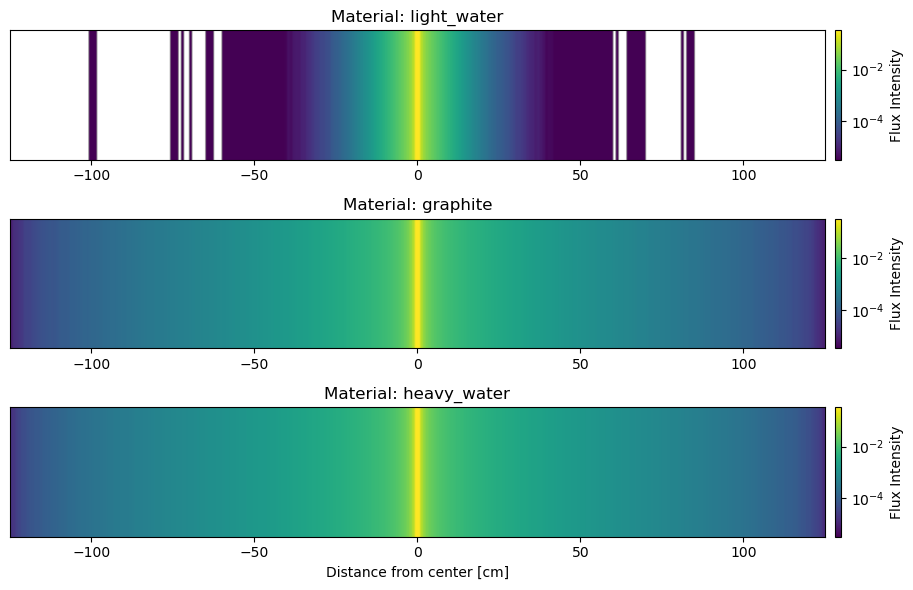

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Calculate global limits to ensure all materials use the same color scale
all_data = np.concatenate([d.flatten() for d in results_2d.values()])
vmax = all_data.max()
vmin = vmax / 1e5  # Show 5 orders of magnitude

fig, axs = plt.subplots(len(results_2d), 1, figsize=(10, 2 * len(results_2d)))

if len(results_2d) == 1: axs = [axs]

for i, (name, data) in enumerate(results_2d.items()):
    # Extract radial slice from the horizontal center
    radial_slice = data[mesh_size // 2, :]
    band = radial_slice.reshape(1, -1)
    
    # Plot using global vmin/vmax for direct comparison
    im = axs[i].imshow(band, cmap='viridis', aspect='auto', 
                       extent=[-sphere_radius, sphere_radius, 0, 0.1],
                       norm=LogNorm(vmin=vmin, vmax=vmax))
    axs[i].set_title(f"Material: {name}")
    axs[i].set_yticks([]) 
    plt.colorbar(im, ax=axs[i], pad=0.01, label='Flux Intensity')

plt.xlabel('Distance from center [cm]')
plt.tight_layout()
plt.show()

While $H_2O$ acts as a powerful shield due to its high absorption, $D_2O$ and graphite behave as efficient diffusers demonstrating the difference in their respective diffusion lengths.

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3.b - 1D-radial flux profile
The 1d radial flux profile is the standard analytical tool for quantifying how neutron flux decreases as it travels through a medium.

Purpose and utility :
- It allows the precise measurement of the attenuation slope, directly related to the material's total cross-section and its ability to stop or scatter neutrons.
- By using a logarithmic Y-axis we can analyze the high flux near the source and the residual flux at the boundary, which would be invisible on a linear scale.
- The line plot provides exact numerical tracking of the flux at any given distance $r$, making it indispensable for safety and shielding thickness calculations.

Material        | Slope      | L (cm)    
----------------------------------------
light_water     | -0.2538    | 3.94
graphite        | -0.0667    | 14.99
heavy_water     | -0.0629    | 15.89


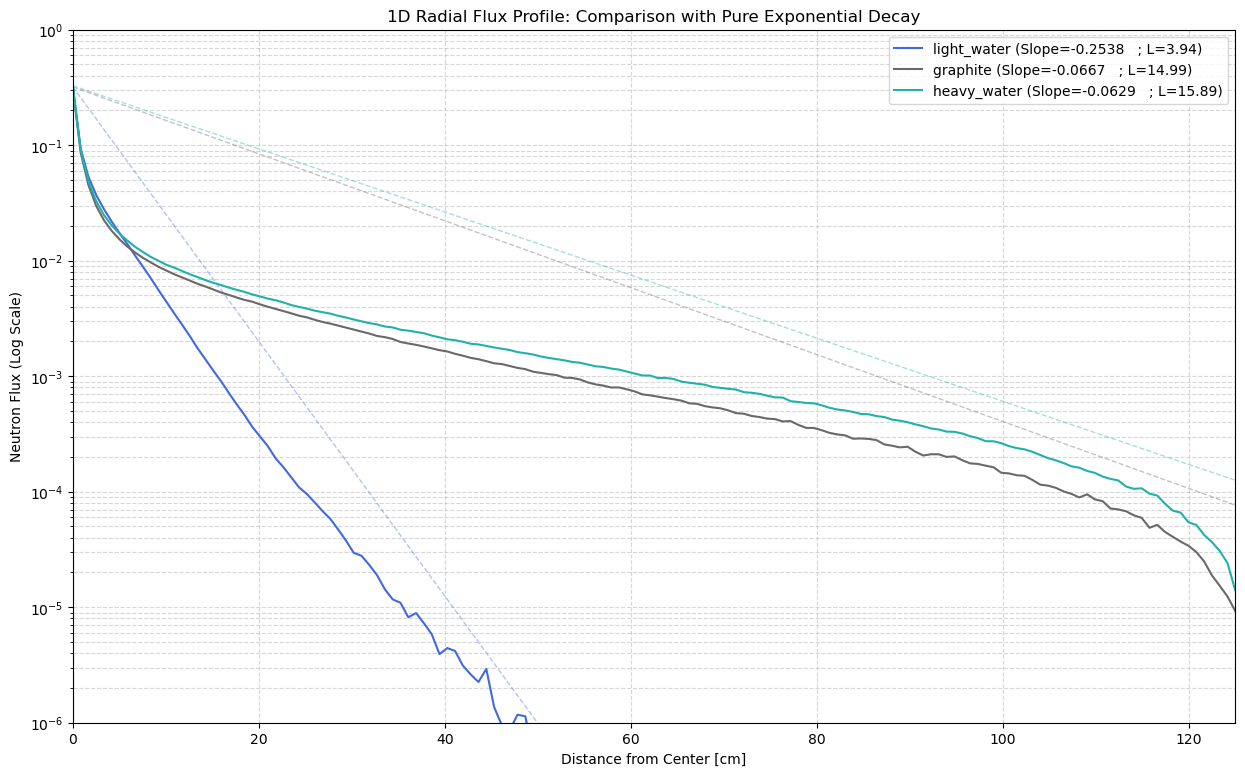

In [15]:
# Define material colors for consistent plotting
material_colors = {
    'light_water': 'royalblue',
    'heavy_water': 'lightseagreen',
    'graphite': 'dimgray'
}

plt.figure(figsize=(15, 9))

print(f"{'Material':<15} | {'Slope':<10} | {'L (cm)':<10}")
print("-" * 40)

for name, data in results_2d.items():
    mid = mesh_size // 2
    radial_slice = data[mid, mid:] 
    x_axis = np.linspace(0, sphere_radius, len(radial_slice))
    color = material_colors.get(name, 'black')

    # slope calculation
    fit_mask = (x_axis >= 5) & (x_axis <= 30)
    slope, _ = np.polyfit(x_axis[fit_mask], np.log(radial_slice[fit_mask] + 1e-15), 1)
    L = -1/slope
    
    # Forced Intercept
    intercept_max = np.log(radial_slice[0] + 1e-15)
    
    print(f"{name:<15} | {slope:<10.4f} | {L:.2f}")

    #Plotting
    plt.semilogy(x_axis, radial_slice, 
                 label=f'{name} (Slope={slope:<10.4f}; L={L:.2f})', 
                 color=color, lw=1.5)
    
    # Pure exponential dashed line
    plt.semilogy(x_axis, np.exp(slope * x_axis + intercept_max), 
                 color=color, ls='--', lw=1, alpha=0.4)
# Formatting
plt.xlabel('Distance from Center [cm]')
plt.ylabel('Neutron Flux (Log Scale)')
plt.title('1D Radial Flux Profile: Comparison with Pure Exponential Decay')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.ylim(1e-6, 1.0) # Keeps the plot clean
plt.xlim(0, 125) # Keeps the plot clean
plt.show()

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3.c - Final Comparative Analysis & Statistical Convergence
The calculated slopes ($\alpha$) from the radial flux profiles provide a quantitative measure of each medium's opacity to thermal neutrons:

| Material | Slope ($\alpha$) | $L_{eff}$ (cm) | Physical Significance |
| :--- | :---: | :---: | :--- |
| **Light water ($H_2O$)** | **-0.2538** | **3.94** | **Prompt Filter:** High absorption decimated the population almost instantly. |
| **Graphite** | **-0.0667** | **14.99** | **Spatial Trap:** High density confines neutrons, leading to moderate attenuation. |
| **Heavy water ($D_2O$)** | **-0.0629** | **15.89** | **Optimal Accumulator:** Lowest gradient, allowing maximum flux propagation. | 

A flatter slope implies that neutrons explore a much larger phase space and survive significantly longer before being terminated by leakage or capture.

While $H_2O$ is restricted to compact shielding or cooling, $D_2O$ and graphite are the only candidates capable of ensuring flux homogeneity in large volumes. In this 125 cm geometry, $D_2O$ offers the best performance.

### &nbsp;&nbsp;&nbsp;&nbsp; 4. 2D-spatial flux distribution
This visualization provides a complete cross-sectional map of the neutron flux across the entire geometry (mathematically redundant in a spherical geometry where the flux depends only on the radial dimension $r$ but useful for all other geometries).

It allows for an intuitive observation of how the flux spreads from the source and attenuates through the material. Moreover, it gives a direct visual shielding comparison by using a common color scale. We can directly compare the opacity of different materials.

The use of a logarithmic scale is vital here to capture the full dynamic range of the flux, ensuring that both the high-intensity center and the lower-intensity periphery are visible in the same image.

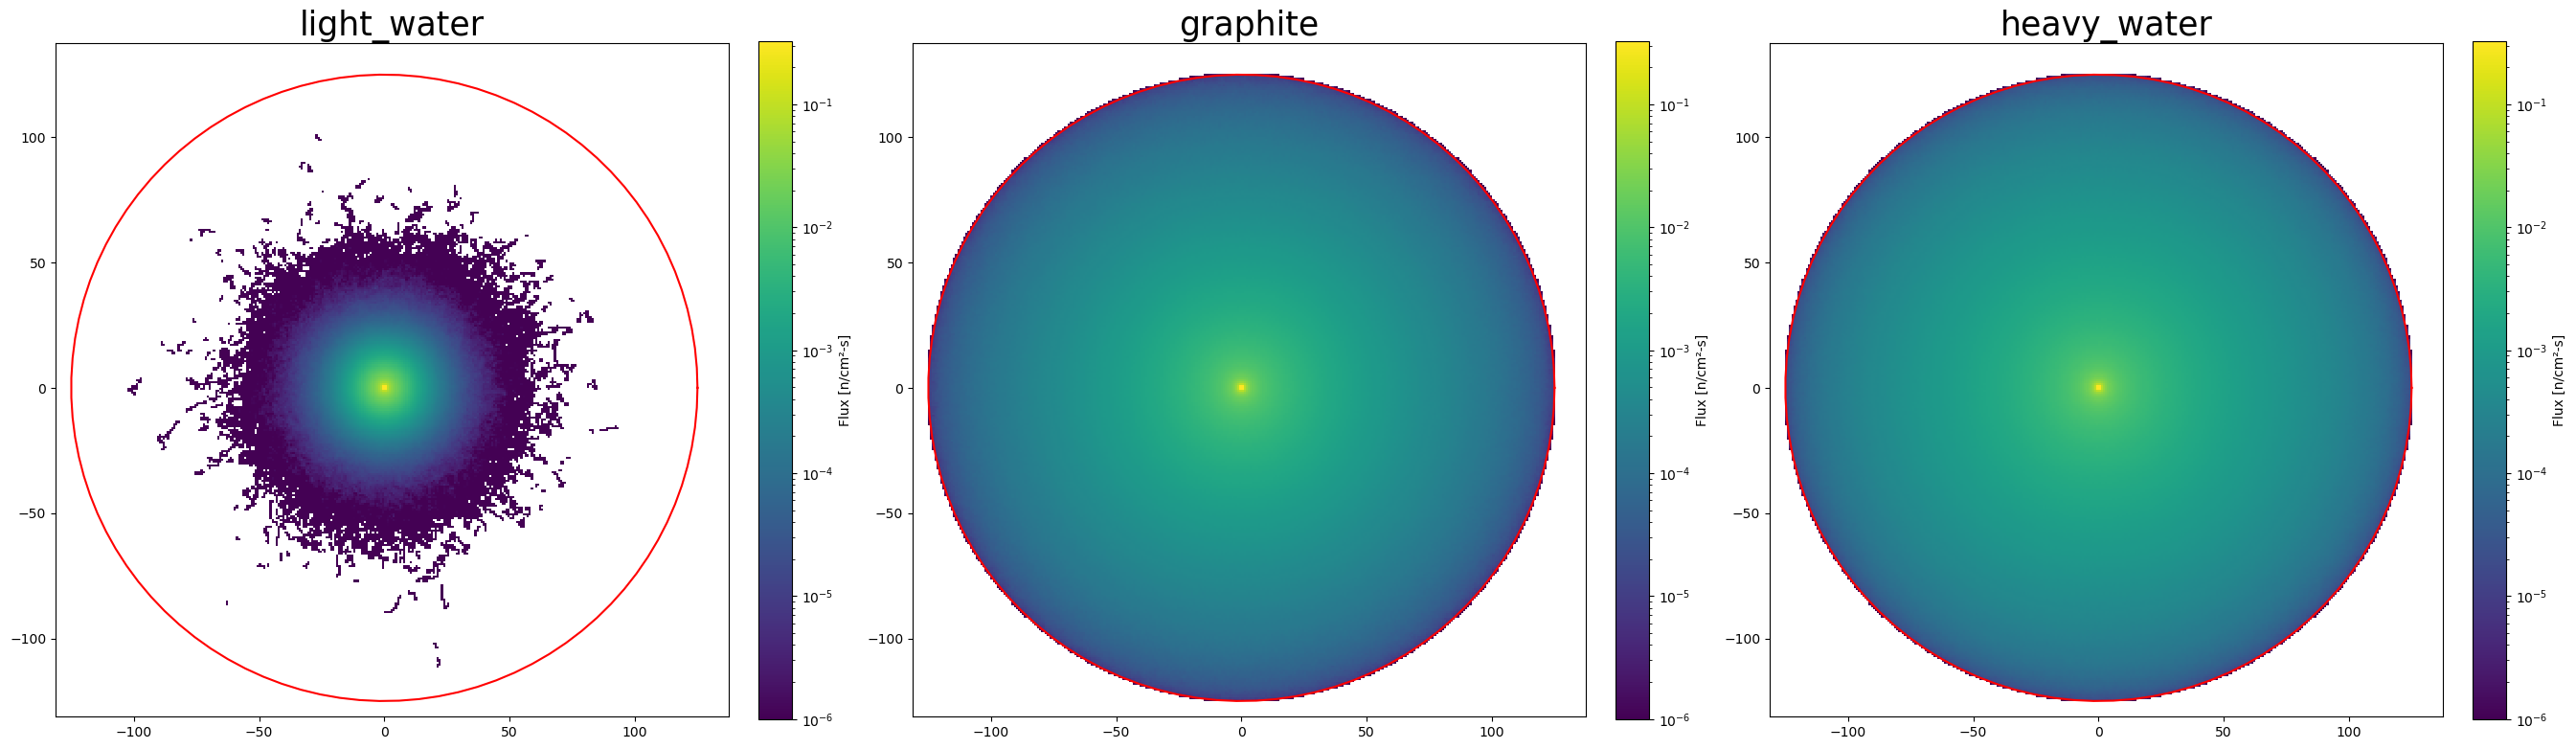

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

# Establish a common normalization scale for consistent visual comparison
vmax_common = max([res.max() for res in results_2d.values()]) 

# Loop on all materials
for i, (mat_obj, name) in enumerate(material_list):
    ax = axes[i]
    data_plot = results_2d[name]
    
    # Render spatial distribution using logarithmic scaling
    im = ax.imshow(data_plot, 
               extent=[-sphere_radius, sphere_radius, -sphere_radius, sphere_radius],
               norm=colors.LogNorm(vmin=1e-6, vmax=vmax_common), 
               cmap='viridis', 
               origin='lower',
               interpolation='none')
    
    # Overlay showing boundary of the geometry
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(sphere_radius*np.cos(theta), sphere_radius*np.sin(theta), color='red', linewidth=1.5)
    
    # Configuration of limits and titles
    ax.set_xlim(-sphere_radius*1.05, sphere_radius*1.1)
    ax.set_ylim(-sphere_radius*1.05, sphere_radius*1.1)
    ax.set_title(f'{name}', fontsize=25)
    
    # Colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Flux [n/cm²-s]')

plt.tight_layout()
plt.show()

The simulation successfully captures the fundamental competition between absorption and diffusion. The results are physically consistent: **$H_2O$** is absorption-dominated, resulting in a localized flux, while **$D_2O$** and **Graphite** are diffusion-dominated, producing a broadly distributed flux.

The 2D flux maps of **$D_2O$** and **Graphite** exhibit a perfectly saturated geometry, reaching a steady state across the entire volume. The sharp boundary indicates that neutrons are escaping the system (**leakage**) rather than being scattered back, confirming that a 125 cm radius is physically "small" for materials with high diffusion lengths.

However, this visual representation alone is insufficient to discriminate between moderators with similar diffusion properties like $D_2O$ and Graphite. Consequently, additional metrics are required to reveal their distinct neutronic behaviors.

### &nbsp;&nbsp;&nbsp;&nbsp; 5. Leakage & economy
The leakage rate quantifies the number of neutrons crossing the outer boundary of the geometry. While it depends heavily on the system's dimensions, it serves as the key metric for evaluating the shielding performance of a specific configuration. This data is critical for determining the required thickness of a shield or for calculating the reflector savings in a reactor core design.

While previous maps and curves illustrate neutron behavior inside the medium, the leakage table offers the final balance sheet of the simulation. It condenses spatial and material data into a single objective number representing the overall effectiveness of the configuration. By calculating the Relative Leakage (%), we normalize the losses against the source strength (1 n/s), allowing a universal comparison regardless of the source intensity.

In [17]:
print(f"{'Material':<15} | {'Leakage (%)':<15} | {'Absorption (%)':<15} | {'Total Loss'}")
print("-" * 70)

for name in results_spectrum.keys():
    # 1. Leakage extraction (Current at the surface)
    total_leak = results_leakage[name]
    rel_leak = (total_leak / 1.0) * 100
    
    # 2. Absorption extraction (Global absorption tally)
    total_abs = results_abs[name]
    rel_abs = (total_abs / 1.0) * 100
    
    # 3. Conservation balance (Should be close to 1.0)
    total_loss = total_leak + total_abs
    
    # Formatted output
    print(f"{name:<15} | {rel_leak:<14.2f}% | {rel_abs:<14.2f}% | {total_loss:.4f}")

    # Small warning if the balance does not close (convergence or tally issue)
    if abs(total_loss - 1.0) > 0.01:
        print("\n[WARNING] Neutron balance deviation > 1%. Check statistics or tally definitions.")
        
    print("-" * 70)

Material        | Leakage (%)     | Absorption (%)  | Total Loss
----------------------------------------------------------------------
light_water     | 0.00          % | 99.98         % | 0.9998
----------------------------------------------------------------------
graphite        | 50.09         % | 49.93         % | 1.0002
----------------------------------------------------------------------
heavy_water     | 90.12         % | 10.39         % | 1.0051
----------------------------------------------------------------------


To distinguish between a material that is "opaque" due to scattering and one that is "opaque" due to capture, we analyze the macroscopic absorption rate.

Light water's spatial collapse of the flux is driven by the high thermal capture cross-section of H-1. The "lost" neutrons are physically removed from the population near the source, preventing the formation of a long-range thermal field. For graphite, the system shows a balanced competition between absorption (49.93 %) and leakage (50.09 %). While it allows some migration, its moderate capture cross-section prevents it from reaching the efficiency of heavy water. Finally, heavy water's (D2O) decrease in flux is almost exclusively due to leakage and geometric attenuation.

### &nbsp;&nbsp;&nbsp;&nbsp; 6. Quantitative Synthesis

In [18]:
header = f"{'Material':<15} | {'Mean Residence Time (s)':<25} | {'M.R. (Theor.)':<15} | {'Physical Behavior'}"
print(header)
print("-" * len(header))

# Theoretical Reference Values from P. Reuss, "Précis de Neutronique"
mr_values = {
    'light_water': 62,
    'heavy_water': 5670,
    'graphite': 216
}

for name in results_time.keys():
    # Mean Residence Time Calculation
    time_centers = np.sqrt(times[:-1] * times[1:])
    time_vals = results_time[name]
    mean_life = np.average(time_centers, weights=time_vals)
    
    # M.R. retrieval
    mr = mr_values.get(name, 0)
    
    # Shield/fileter behavioral classification
    behavior = "Shield / Filter" if mr < 100 else "Moderator / Storage"
    
    print(f"{name:<15} | {mean_life:<25.2e} | {mr:<15} | {behavior}")

Material        | Mean Residence Time (s)   | M.R. (Theor.)   | Physical Behavior
---------------------------------------------------------------------------------
light_water     | 1.54e-04                  | 62              | Shield / Filter
graphite        | 3.14e-03                  | 216             | Moderator / Storage
heavy_water     | 4.18e-03                  | 5670            | Moderator / Storage


#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 6.a - The moderating ratio (M.R.)
The actual efficiency of a moderator is not only defined by its ability to slow down neutrons, it depends on its capacity to thermalize them without capturing them. The physical performance criterion is called the **moderating ratio (M.R.)** define by the ratio between the moderating power and the macroscopic absorption cross-section ($\Sigma_a$):

The performance of a moderator is first evaluated by its **moderating power** ($\xi \Sigma_s$). As defined in the **"Précis de neutronique"; Paul REUSS**, this parameter characterizes the material's ability to slow down neutrons. 

However, this must be divided by the macroscopic absorption cross-section ($\Sigma_a$) to calculate "how many units of slowing down" you get for every "unit of capture risk", to quantify the probability of a neutron reaching thermal energy before being captured. 

This ratio, known as the **moderating ratio (M.R.)**, represents the efficiency of the thermalization process relative to the probability of capture:

$$M.R. = \frac{\text{moderating power}}{\Sigma_a} = \frac{\xi \Sigma_s}{\Sigma_a}$$

Using the data from of the **"Précis de neutronique"; Paul. REUSS** (Tables 7.4 and 7.1 page 178), we can reconstruct the neutron balance for each medium:
| Material | $\sigma_a$ (barns) | Conc. $N$ ($10^{24}$ at/cm³) | **$\Sigma_a$ ($cm^{-1}$)** | Moderating power ($\xi \Sigma_s$) | **M.R.** (Calculated) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Light water ($H_2O$)** | 0.332 (H) | 0.03337 | 0.02216 | 1.3772 | **~62** |
| **Graphite (C)** | 0.00337 (C) | 0.0802 | 0.00027 | 0.0604 | **~224** |
| **Heavy water ($D_2O$)** | 0.00051 (D) | 0.0332 | 0.0000338 | 0.1795 | **~5310** |

This demonstration explains the results obtained in our simulation. For light water, despite possessing the highest moderating power (1.3772), its high thermal capture cross-section leads to a significantly low moderating ratio of approximately 62. This indicates that the probability of a neutron surviving the thermalization process is almost zero, directly confirming the 99.98% absorption observed in the simulation tally. In contrast, graphite exhibits an intermediate moderating ratio of approximately 224, which allows for partial neutron survival and results in a balanced competition between leakage (50.09%) and absorption (49.93%). Finally, heavy water represents the most extreme case; although its moderating power is nearly eight times lower than that of light water, its absorption is almost non-existent. This causes the moderating ratio to explode to approximately 5310, creating a "transparent" medium that facilitates long-distance diffusion justifying the high leakage rate of 90.12%.

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 6.c - Final discussion on material selection
The numerical results explain the "visual paradox" observed in the 2d spatial flux maps of **$H_2O$**, even though it is the most efficient at slowing neutrons down (highest $\xi$), its low M.R. and very short mean life ($\tau$) make it a poor candidate for large-scale thermal fields. **$D_2O$** 's M.R. is nearly **100 times higher** than that of light water. This allows neutrons to persist in the system for milliseconds, enabling the "accumulation effect" seen in the temporal plateau and the high leakage values. For $H_2O$, the 125 cm radius is effectively "infinite" (the flux reaches zero). For $D_2O$ and graphite, the 125 cm radius is "thin," as evidenced by the high residence time and high leakage, meaning the neutrons have not yet exhausted their diffusion potential.

## XII. Final conclusion and engineering perspectives

This computational study successfully benchmarked the neutronic properties of light water ($H_2O$), heavy water ($D_2O$), and graphite using a Monte Carlo approach. By focusing on an "iso-distance" 125 cm geometry, we have effectively isolated the impact of microscopic cross-sections on macroscopic reactor parameters.

### &nbsp;&nbsp;&nbsp;&nbsp; 1. Physics validation
The simulation highlights a fundamental neutronic divergence between the three reference materials :

| Material | Diffusion length (L) | Leakage (125 cm) | Physical regime |
| :--- | :--- | :--- | :--- |
| **Light water** | $\approx$ 2 cm | $\approx$ 0.02% | Absorption dominated |
| **Graphite** | $\approx$ 15 cm | $\approx$ 50% | Diffusion dominated |
| **Heavy water** | $\approx$ 18 cm | Maximal (~90%) | Optimal moderator |

Despite having the highest moderating power ($\xi\Sigma_s$), **$H_2O$** suffers from a "punitive" capture cross-section ($^1H(n,\gamma)^2H \approx 0.332 b$). The flux is thermalized instantaneously but self-consumed and any captured neutron represents a direct loss in reactor power. At a 125 cm radius, the medium is effectively infinite (which is normal as 125 cm was chosen to reach 0% leakage).

**$D_2O$ & graphite** exhibit exceptionally high moderating ratios (up to 5310 for $D_2O$). This allows for a sustained thermal flux and high residence times. At this scale, they are physically "thin," meaning they do not just moderate neutrons, they transport them.

### &nbsp;&nbsp;&nbsp;&nbsp; 2. Industrial implications & reactor design
These results confirm and justify the historical and technological choices of the nuclear industry :
* **$H_2O$ :** Allows for highly reduced core volumes (e.g., nuclear submarines). However, this compactness requires enriched uranium to compensate for the neutrons "stolen" by hydrogen capture.
* The near-zero capture of **$D_2O$** and **graphite** prioritizes neutron survival. The 90% leakage rate for $D_2O$ in this study proves that natural uranium reactors must be voluminous (several meters) to reach criticality, bypassing the need for enrichment.

### &nbsp;&nbsp;&nbsp;&nbsp; 3. Neutronic analysis based on cpu runtime

| Material | CPU runtime (s) |
| :--- | :---: |
| Light water ($H_2O$) | $\approx 993 \text{ s}$ |
| Graphite | $\approx 2808 \text{ s}$ |
| Heavy water ($D_2O$) | $\approx 6801 \text{ s}$ |

The observed disparity in CPU runtimes is a direct macroscopic signature of the microscopic physics at play. In a Monte Carlo simulation, the computational cost is proportional to the total number of simulated events (scattering, boundary crossing) rather than the initial particle count. **Light water ($H_2O$)** acts as a "prompt filter." Due to the high moderation power of the Hydrogen atoms ($H$) within the molecule and their significant thermal capture cross-section, neutrons are thermalized in only $\approx 18$ collisions (source: J.R. Lamarsh, "Introduction to Nuclear Engineering") and quickly absorbed leading to fewer so a shorter calculation time. **Graphite & heavy water ($D_2O$)** act as "neutron accumulators." In graphite, thermalization requires $\approx 115$ collisions against Carbon atoms ($C$) whereas in heavy water it requires $\approx 25$ collisions against Deuterium atoms ($D$). Combined with a near-zero absorption cross-section, neutrons survive significantly longer, undergoing thousands of additional thermal scattering events ($S(\alpha, \beta)$) and mesh crossings before leaking or being absorbed.

To validate quantitatively, we define the factor $F$ by the sum of slowing-down collisions ($n_{sd}$) and thermal diffusion events ($n_{th}$):
$$F \approx \frac{(n_{sd} + n_{th})_{material}}{(n_{sd} + n_{th})_{H_2O}}$$


| Moderator | $n_{sd}$ (to 0.025 eV) | Thermal Survival ($\sigma_s / \sigma_a$) | Complexity Factor ($F$) | Physical Driver |
| :--- | :---: | :---: | :---: | :--- |
| **Light water ($H_2O$)** | $\approx 18$ | Very Low ($\approx 20$) | **1.0** | high $H$ capture |
| **Graphite ($C$)** | $\approx 115$ | High ($\approx 1370$) | **$\approx 2.8$** | 6.4x more $n_{sd}$ collisions |
| **Heavy water ($D_2O$)** | $\approx 25$ | Extreme ($\approx 27000$) | **$\approx 3.5$** | Infinite thermal tracking (almost no absorbption) |


The CPU runtime is not merely a benchmark of hardware performance; it serves as a macroscopic validation of **neutron economy**, illustrating the inherent trade-off between physical fidelity and computational overhead. The recorded runtimes of **993 s** for **$H_2O$**, **2808 s** for **graphite** (F = 2.82) are highly consistent with the theoretical complexity factors calculated. This correlation provides an additional, independent metric for the physical consistency and reliability of the Monte Carlo simulation across different moderating environments. However, the 6801 s runtime for $D_2O$ ($F = 6.84$) significantly exceeds the initial linear prediction ($F = 3.48$). The slight but critical difference between the graphite slope (**-0.0667**) and the heavy water slope (**-0.0629**) is the direct cause of the observed disparity in CPU runtimes. Although the numerical difference seems small ($0.0038$), it represents **thousands of additional scattering events** per neutron at the microscopic level. It's the macroscopic signature of near-zero absorption (while $H_2O$ and graphite eventually terminate the calculation through capture, $D_2O$ forces the CPU into an exhaustive thermal random walk. The neutron survives for thousands of additional scattering events).

### &nbsp;&nbsp;&nbsp;&nbsp; 4. Complementary analysis
Knowing the **leakage rate** is not relevant without knowing the **leakage spectrum** (which indicates the proportion of thermalized neutrons at the exit (the moderator's goal)). However, an analysis of the leakage spectra with an **iso-distance study** giving such different leakage rates (0% to 90%) would have no physical relevance. This is why, for a better moderator study, an **iso-leakage** study is necessary.

This framework demonstrates that the ideal moderator is not the one that stops neutrons the fastest, but the one that offers the best compromise between moderating power and neutronic transparency. It is this moderating ratio that determines, $in fine$, the physical dimensions and fuel choices of each nuclear reactor fleet.
However, the industrial choice is not limited to raw neutronic performance. While heavy water and graphite allow for the use of natural uranium, light water ($H_2O$) has prevailed due to major practical advantages : its ability to make reactors passively self-stable, its ease of access, and its role as a compact biological shield. It demonstrates that reactor design results of a trade-off between neutronic economy, intrinsic safety, and the desired power density.